# 04 Figures

Build the three figures and save them to `results/figures/`. Fig 1 reads the raw files (it starts in 2000, before the merged sample); Figs 2–3 read `data/processed/`.

In [6]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import importlib, plot_style
importlib.reload(plot_style)     # pick up edits to plot_style.py without restarting the kernel
from plot_style import apply_style, COLORS, PIECES, SITE, source_note

ROOT = Path.cwd().parent     
raw_dir = ROOT / "data" / "raw"
proc_dir = ROOT / "data" / "processed"
fig_dir = ROOT / "results" / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

apply_style()

df = pd.read_csv(proc_dir / "monthly.csv", index_col="date", parse_dates=True)
contrib = pd.read_csv(proc_dir / "contributions.csv", index_col="date", parse_dates=True)

# Label
EVENTS = {"2022-03-01": ("First hike", "right"), "2022-06-01": ("QT starts", "left"), "2024-09-01": ("First cut", "center")}

def mark_events(ax, labels=True):
    for d, (name, ha) in EVENTS.items():
        ax.axvline(pd.Timestamp(d), color=COLORS["grey"], ls="--", lw=1, zorder=0)
        if labels:
            ax.text(pd.Timestamp(d), 1.01, name, transform=ax.get_xaxis_transform(),
                    ha=ha, va="bottom", fontsize=9, color=COLORS["grey"])

## Fig 1: mortgage rate = 10-year Treasury + spread, 2000 to present

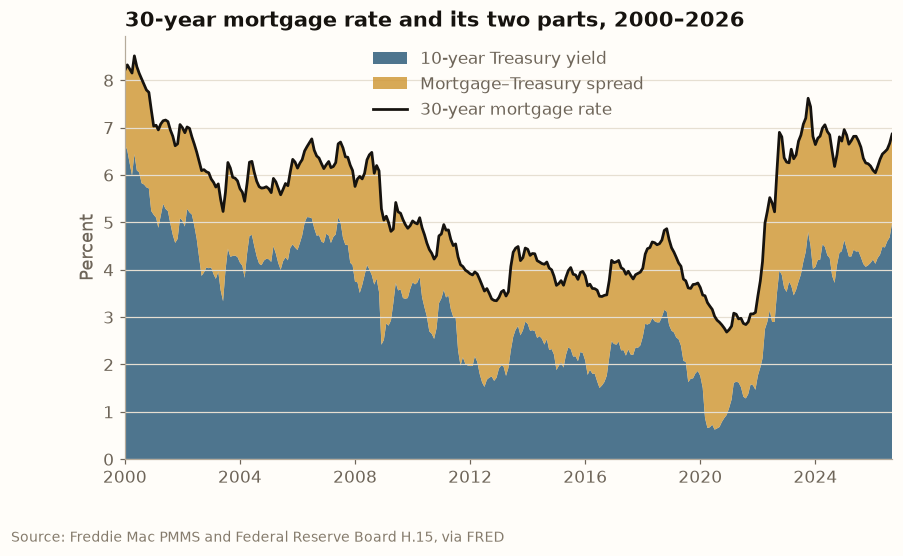

In [7]:
lvl = pd.concat([
    pd.read_csv(raw_dir / f"{sid}.csv", index_col="date", parse_dates=True).resample("MS").mean()
    for sid in ["MORTGAGE30US", "DGS10"]
], axis=1, join="inner")
lvl = lvl.loc["2000-01-01":df.index.max()]
lvl["spread"] = lvl["MORTGAGE30US"] - lvl["DGS10"]

fig, ax = plt.subplots()
ax.stackplot(lvl.index, lvl["DGS10"], lvl["spread"],
             colors=[COLORS["part1"], COLORS["part2"]], alpha=0.85,
             labels=["10-year Treasury yield", "Mortgage–Treasury spread"])
ax.plot(lvl.index, lvl["MORTGAGE30US"], color=COLORS["total"], lw=1.8, label="30-year mortgage rate")
ax.set_title("30-year mortgage rate and its two parts, 2000–2026")
ax.set_ylabel("Percent")
ax.set_ylim(0, None)
ax.set_xlim(lvl.index.min(), lvl.index.max())
ax.xaxis.set_major_locator(mdates.YearLocator(4))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(loc="upper center")
source_note(fig, "Freddie Mac PMMS and Federal Reserve Board H.15, via FRED")
fig.savefig(fig_dir / "fig1_levels.png")
plt.show()

## Fig 2: contributions to the change in the mortgage rate since January 2021

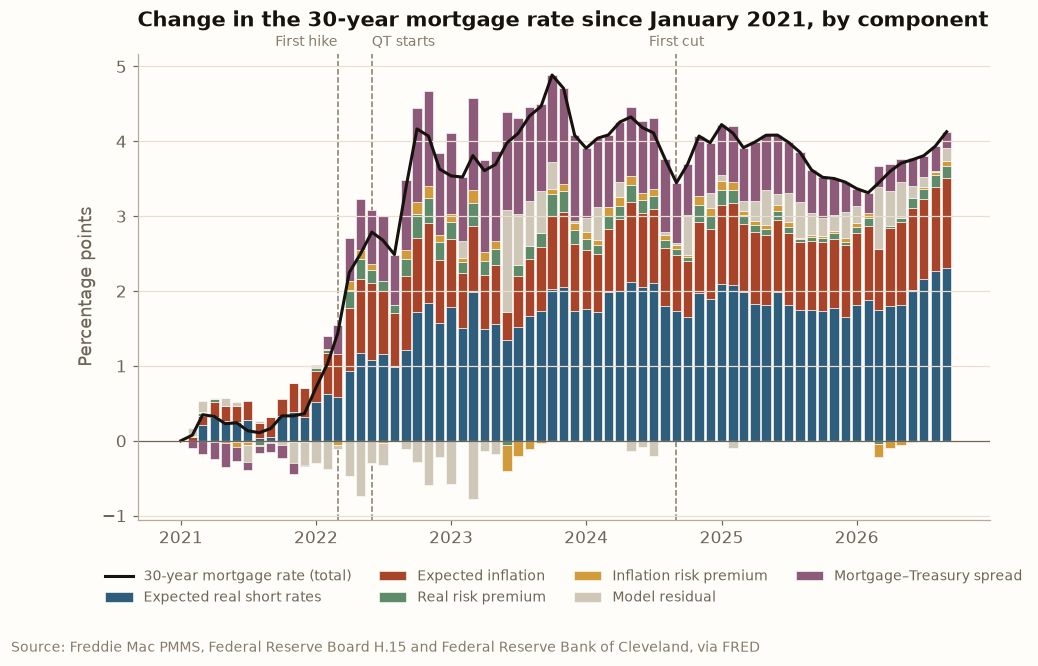

In [8]:
parts = {
    "exp_real_path_10Y":  ("Expected real short rates", PIECES["exp_real_path"]),
    "exp_infl_10Y":       ("Expected inflation",        PIECES["exp_infl"]),
    "real_risk_prem_10Y": ("Real risk premium",         PIECES["real_rp"]),
    "infl_risk_prem_10Y": ("Inflation risk premium",    PIECES["infl_rp"]),
    "cleveland_resid":    ("Model residual",            PIECES["resid"]),
    "spread":             ("Mortgage–Treasury spread",  PIECES["spread"]),
}

fig, ax = plt.subplots(figsize=(10, 5.5))
pos_base = pd.Series(0.0, index=contrib.index)
neg_base = pd.Series(0.0, index=contrib.index)
width = 25    # days
for col, (label, color) in parts.items():
    v = contrib[col]
    bottom = pos_base.where(v >= 0, neg_base)
    ax.bar(contrib.index, v, bottom=bottom, width=width, color=color, label=label,
           edgecolor=SITE["paper"], linewidth=0.4)
    pos_base = pos_base + v.clip(lower=0)
    neg_base = neg_base + v.clip(upper=0)
ax.plot(contrib.index, contrib["total"], color=COLORS["total"], lw=2, label="30-year mortgage rate (total)")
ax.axhline(0, color=SITE["muted"], lw=0.8)
mark_events(ax)
ax.set_title("Change in the 30-year mortgage rate since January 2021, by component", pad=18)
ax.set_ylabel("Percentage points")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), fontsize=9, ncol=4)
source_note(fig, "Freddie Mac PMMS, Federal Reserve Board H.15 and Federal Reserve Bank of Cleveland, via FRED", y=-0.09)
fig.savefig(fig_dir / "fig2_contributions.png")
plt.show()

## Fig 3: the spread, Fed MBS holdings and rate volatility

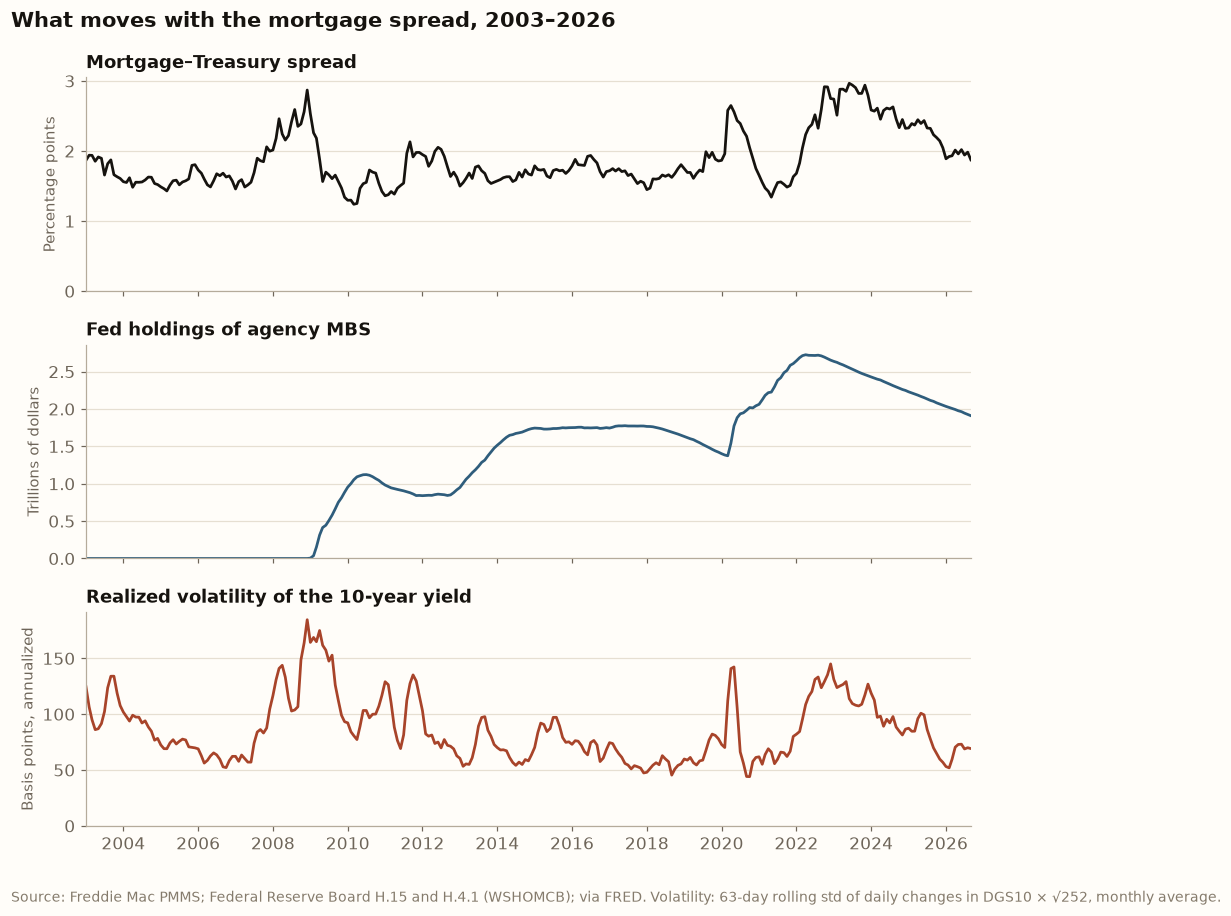

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
panels = [
    ("spread",   "Mortgage–Treasury spread", "Percentage points", COLORS["total"]),
    ("mbs_trn",  "Fed holdings of agency MBS", "Trillions of dollars", COLORS["part1"]),
    ("vol10_bp", "Realized volatility of the 10-year yield", "Basis points, annualized", COLORS["accent"]),
]
for ax, (col, title, unit, color) in zip(axes, panels):
    ax.plot(df.index, df[col], color=color)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel(unit, fontsize=10)
    ax.set_ylim(0, None)
axes[-1].set_xlim(df.index.min(), df.index.max())
axes[-1].xaxis.set_major_locator(mdates.YearLocator(2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.suptitle("What moves with the mortgage spread, 2003–2026", x=0.01, ha="left",
             fontsize=14, fontweight="bold")
fig.tight_layout()
source_note(fig, "Freddie Mac PMMS; Federal Reserve Board H.15 and H.4.1 (WSHOMCB); via FRED. "
            "Volatility: 63-day rolling std of daily changes in DGS10 × √252, monthly average.")
fig.savefig(fig_dir / "fig3_spread_drivers.png")
plt.show()